The dataset includes the following columns:

- Recency_bins: Categories for recency.
- Frequency_bins: Categories for frequency.
- Category: The product category.
- Product_Count: The count of products in each combination of Recency_bins and Frequency_bins.

To create the desired graph for Frequency_bins vs. Product_Count, we can aggregate Product_Count over the Frequency_bins by summing across all Recency_bins and Categories.

In [1]:
import pandas as pd

# Load the uploaded file to examine its structure
file_path = 'data/category_counts.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
data.head()


,Recency_bins,Frequency_bins,Category,Product_Count
0,"(-0.001, 1.0]","(-0.001, 1.0]",ACCESORIOS COSMETICOS,0
1,"(-0.001, 1.0]","(-0.001, 1.0]",BIJOUTERIE,0
2,"(-0.001, 1.0]","(-0.001, 1.0]",COMPLEMENTOS,0
3,"(-0.001, 1.0]","(-0.001, 1.0]",CUIDADO PERSONAL,0
4,"(-0.001, 1.0]","(-0.001, 1.0]",FRAGANCIAS,0


#### Here's the graph showing the aggregated product counts for each frequency bin.

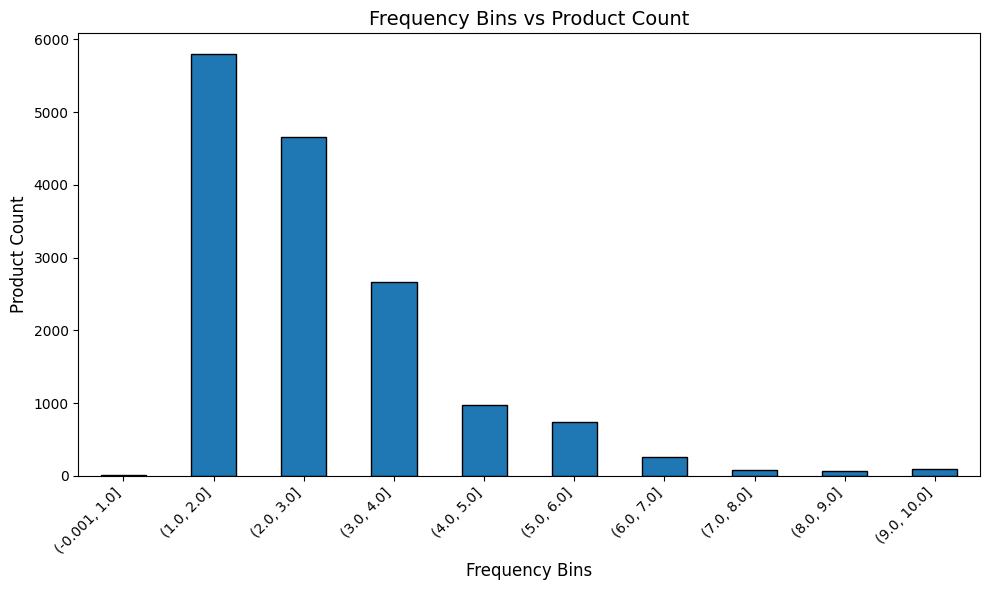

In [2]:
import matplotlib.pyplot as plt

# Aggregate the product counts by Frequency_bins
frequency_bins_agg = data.groupby('Frequency_bins')['Product_Count'].sum()

# Plot the Frequency_bins vs Product_Count
plt.figure(figsize=(10, 6))
frequency_bins_agg.plot(kind='bar', edgecolor='black')
plt.title('Frequency Bins vs Product Count', fontsize=14)
plt.xlabel('Frequency Bins', fontsize=12)
plt.ylabel('Product Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Here is the graph showing the aggregated product counts for each recency bin

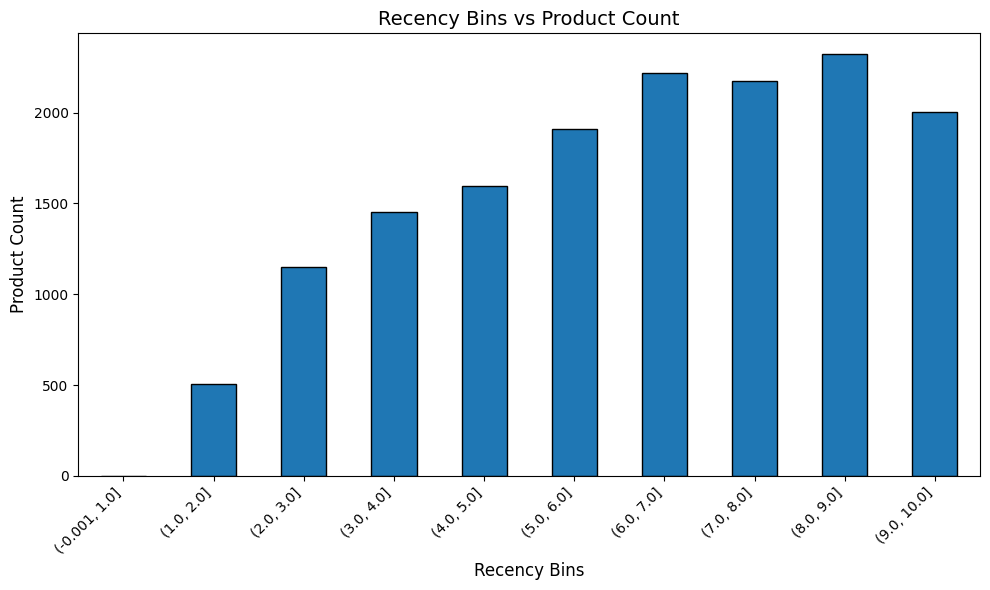

In [3]:
# Aggregate the product counts by Recency_bins
recency_bins_agg = data.groupby('Recency_bins')['Product_Count'].sum()

# Plot the Recency_bins vs Product_Count
plt.figure(figsize=(10, 6))
recency_bins_agg.plot(kind='bar', edgecolor='black')
plt.title('Recency Bins vs Product Count', fontsize=14)
plt.xlabel('Recency Bins', fontsize=12)
plt.ylabel('Product Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### These weights reflect the relative importance of frequency and recency based on their variability, with recency having a slightly higher weight due to its greater entropy.

In [4]:
import numpy as np

# Function to calculate entropy
def calculate_entropy(data):
    probabilities = data / data.sum()
    # Filter out zero probabilities to avoid log issues
    probabilities = probabilities[probabilities > 0]
    entropy = -np.sum(probabilities * np.log(probabilities))
    return entropy

# Calculate entropy for Frequency_bins and Recency_bins
frequency_entropy = calculate_entropy(frequency_bins_agg)
recency_entropy = calculate_entropy(recency_bins_agg)

# Calculate weights
total_entropy = frequency_entropy + recency_entropy
alpha = frequency_entropy / total_entropy
beta = recency_entropy / total_entropy

# Display results
frequency_entropy, recency_entropy, alpha, beta

(np.float64(1.509004788888652),
 np.float64(2.1341818628744837),
 np.float64(0.4141991429833447),
 np.float64(0.5858008570166553))

#### Heatmap analysis with "Most Informative Square Highlighted"

In [7]:
# Plot the heatmap for product counts with the most informative square highlighted
plt.figure(figsize=(12, 8))
ax = sns.heatmap(product_count_heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': '# Products'})
plt.gca().invert_yaxis()  # Invert the y-axis for consistency

# Highlight the most informative square
ax.add_patch(plt.Rectangle(
    (closest_square[0] - product_count_heatmap_data.columns.min(),
     closest_square[1] - product_count_heatmap_data.index.min()),
    1, 1, fill=False, edgecolor='red', lw=3, clip_on=False))

plt.title('Heatmap of Recency (X) vs Frequency (Y) Product Counts (Most Informative Square Highlighted)', fontsize=14)
plt.xlabel('Recency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()



NameError: name 'product_count_heatmap_data' is not defined

<Figure size 1200x800 with 0 Axes>